# Nigeria Renewable Energy Source Analysis

**Data Source**: Illustrative dataset based on documented regional trends in Nigerian solar irradiance and electricity access. Not sourced from a specific official dataset

**Objective**: To analyse the relationship between renewable energy potential and electricity access across Nigerian states, and identify priority areas for solar energy investment.

**Tools**: Python, Pandas, Matplotlib

In [15]:
# Importing needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Ready")

Ready


In [18]:
# Adding the renewable energy sources dataset

renewable_data = {
    "state": ["Lagos", "Kano", "Rivers", "Kaduna", "Oyo", "Anambra", 
              "Delta", "Enugu", "Borno", "Niger", "Sokoto", "Kebbi"],
    "region": ["South", "North", "South", "North", "South", "South", 
               "South", "South", "North", "North", "North", "North"],
    "solar_irradiance_kwh_m2": [4.8, 6.2, 4.5, 5.9, 5.1, 4.9, 
                                 4.6, 5.0, 6.5, 5.7, 6.8, 6.4],
    "wind_speed_ms": [2.1, 4.2, 1.8, 3.9, 2.4, 2.0, 
                      1.9, 2.3, 4.8, 3.5, 5.1, 4.7],
    "current_renewable_mw": [85, 12, 45, 28, 32, 18, 
                              52, 22, 5, 38, 8, 6]
}

df_renewable = pd.DataFrame(renewable_data)
print(df_renewable)

      state region  solar_irradiance_kwh_m2  wind_speed_ms  \
0     Lagos  South                      4.8            2.1   
1      Kano  North                      6.2            4.2   
2    Rivers  South                      4.5            1.8   
3    Kaduna  North                      5.9            3.9   
4       Oyo  South                      5.1            2.4   
5   Anambra  South                      4.9            2.0   
6     Delta  South                      4.6            1.9   
7     Enugu  South                      5.0            2.3   
8     Borno  North                      6.5            4.8   
9     Niger  North                      5.7            3.5   
10   Sokoto  North                      6.8            5.1   
11    Kebbi  North                      6.4            4.7   

    current_renewable_mw  
0                     85  
1                     12  
2                     45  
3                     28  
4                     32  
5                     18  
6   

In [19]:
# Adding the electricity access dataset

access_data = {
    "state": ["Lagos", "Kano", "Rivers", "Kaduna", "Oyo", "Anambra", 
              "Delta", "Enugu", "Borno", "Niger", "Sokoto", "Kebbi"],
    "electricity_access_pct": [72, 45, 61, 38, 55, 63, 58, 60, 22, 31, 19, 24],
    "population_millions": [15.3, 13.1, 7.3, 8.9, 8.0, 5.5, 5.8, 4.6, 5.9, 6.1, 4.9, 4.4],
    "peak_demand_mw": [2800, 1200, 980, 750, 890, 620, 710, 580, 420, 510, 380, 350],
    "grid_connected": [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
}

df_access = pd.DataFrame(access_data)
print(df_access)

      state  electricity_access_pct  population_millions  peak_demand_mw  \
0     Lagos                      72                 15.3            2800   
1      Kano                      45                 13.1            1200   
2    Rivers                      61                  7.3             980   
3    Kaduna                      38                  8.9             750   
4       Oyo                      55                  8.0             890   
5   Anambra                      63                  5.5             620   
6     Delta                      58                  5.8             710   
7     Enugu                      60                  4.6             580   
8     Borno                      22                  5.9             420   
9     Niger                      31                  6.1             510   
10   Sokoto                      19                  4.9             380   
11    Kebbi                      24                  4.4             350   

    grid_co

In [20]:
# Merging the two tables

df = pd.merge(df_renewable, df_access, on= 'state')
print(df.shape)
print(df.columns.tolist())

(12, 9)
['state', 'region', 'solar_irradiance_kwh_m2', 'wind_speed_ms', 'current_renewable_mw', 'electricity_access_pct', 'population_millions', 'peak_demand_mw', 'grid_connected']


In [7]:
print(df.describe())

       solar_irradiance_kwh_m2  wind_speed_ms  current_renewable_mw  \
count                12.000000      12.000000             12.000000   
mean                  5.533333       3.225000             29.250000   
std                   0.811657       1.270021             23.386573   
min                   4.500000       1.800000              5.000000   
25%                   4.875000       2.075000             11.000000   
50%                   5.400000       2.950000             25.000000   
75%                   6.250000       4.325000             39.750000   
max                   6.800000       5.100000             85.000000   

       electricity_access_pct  population_millions  peak_demand_mw  \
count               12.000000            12.000000       12.000000   
mean                45.666667             7.483333      849.166667   
std                 18.312109             3.446166      665.397466   
min                 19.000000             4.400000      350.000000   
25%       

In [21]:
# Collecting the solar irradiance by region

solar_irradiance_region = df.groupby('region')['solar_irradiance_kwh_m2'].mean()
print(solar_irradiance_region)

region
North    6.250000
South    4.816667
Name: solar_irradiance_kwh_m2, dtype: float64


In [22]:
# Collecting the electricity access by region

electricity_access_region = df.groupby('region')['electricity_access_pct'].mean()
print(electricity_access_region)

region
North    29.833333
South    61.500000
Name: electricity_access_pct, dtype: float64


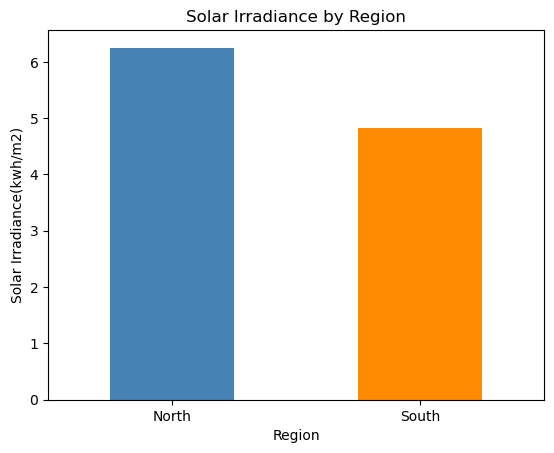

In [23]:
#Plotting Solar irradiance by region

solar_irradiance_region.plot(kind = 'bar', color = ['steelblue', 'darkorange'])
plt.title('Solar Irradiance by Region')
plt.xlabel('Region')
plt.ylabel('Solar Irradiance(kwh/m2)')
plt.xticks(rotation=0)
plt.show()

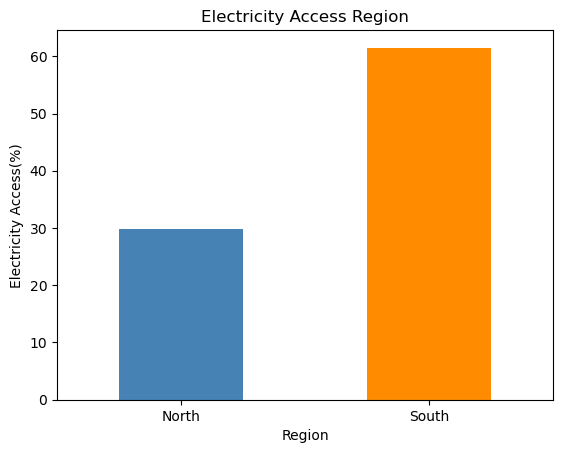

In [24]:
#Plotting electricity access by region

electricity_access_region.plot(kind = 'bar', color = ['steelblue', 'darkorange'])
plt.title('Electricity Access Region')
plt.xlabel('Region')
plt.ylabel('Electricity Access(%)')
plt.xticks(rotation=0)
plt.show()

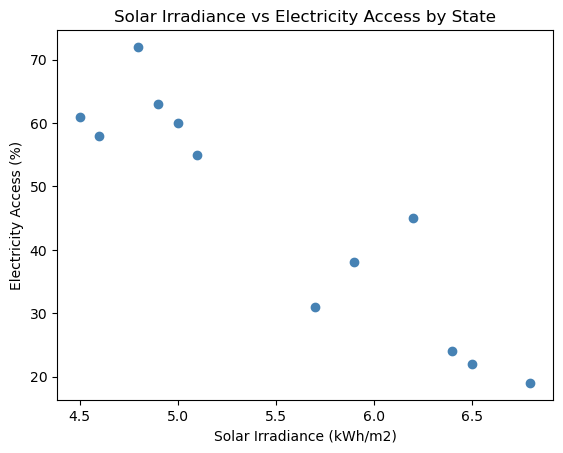

In [25]:
#Plotting the scatter plot of solar irradiance vs electricity access by state

plt.scatter(df['solar_irradiance_kwh_m2'], df['electricity_access_pct'], color='steelblue')
plt.title('Solar Irradiance vs Electricity Access by State')
plt.xlabel('Solar Irradiance (kWh/m2)')
plt.ylabel('Electricity Access (%)')
plt.show()

In [13]:
# Calculate the correlation 

correlation = df['solar_irradiance_kwh_m2'].corr(df['electricity_access_pct'])
print(f"Correlation between solar irradiance and electricity access: {correlation:.2f}")

Correlation between solar irradiance and electricity access: -0.92


In [26]:
# Determine the priority states

print(df[(df['solar_irradiance_kwh_m2'] > 5.5) & (df['electricity_access_pct'] < 40)][['state', 'solar_irradiance_kwh_m2', 'electricity_access_pct']])

     state  solar_irradiance_kwh_m2  electricity_access_pct
3   Kaduna                      5.9                      38
8    Borno                      6.5                      22
9    Niger                      5.7                      31
10  Sokoto                      6.8                      19
11   Kebbi                      6.4                      24


# Findings
The prevalent data suggests that the Northern region of Nigeria averages 6.25 kWh/m² of solar irradiance compared to 4.82 kWh/m² in the South, while also having less electricity access at 29.8% versus 61.5% in the South.

A correlation of -0.92 between solar irradiance and electricity access confirms a strong inverse relationship across Nigeria — states with the highest solar potential had the lowest electricity access, suggesting a systematic misalignment between renewable energy opportunity and infrastructure investment.

The following states were marked as priority after discovering they had the highest solar irradiance while having the lowest electricity access: Kaduna, Borno, Niger, Sokoto, Kebbi respectively